In [1]:
# ============================================================
# INSTALL PDF LIBRARY
# ============================================================

%pip install --upgrade pymupdf
import pymupdf as fitz


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# 1. IMPORTS AND PROJECT FOLDERS
# ============================================================

from pathlib import Path
import os
import re
import json

import fitz
import pandas as pd
import numpy as np

from tqdm.auto import tqdm
from PIL import Image as PILImage
from IPython.display import display, Image


# ------------------------------------------------------------
# Update this only if your folder is stored somewhere else
# ------------------------------------------------------------

PROJECT_DIR = (
    Path.home()
    / "Desktop"
    / "Hackathon2"
)

DATA_DIR = (
    PROJECT_DIR
    / "Data"
)

OUTPUT_DIR = (
    PROJECT_DIR
    / "Outputs"
)

CACHE_DIR = (
    PROJECT_DIR
    / "Cache"
)

QA_PATH = (
    PROJECT_DIR
    / "qa_set.csv"
)


# ------------------------------------------------------------
# Create writable folders
# ------------------------------------------------------------

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

os.chdir(
    PROJECT_DIR
)


print("=" * 90)
print("PROJECT SETUP")
print("=" * 90)

print("\nProject folder:")
print(
    PROJECT_DIR
)

print("\nCurrent working directory:")
print(
    Path.cwd()
)

print("\nWritable:")
print(
    os.access(
        Path.cwd(),
        os.W_OK
    )
)

PROJECT SETUP

Project folder:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2

Current working directory:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2

Writable:
True


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ============================================================
# HELPER FUNCTION: CREATE SAFE FILE NAMES
# ============================================================

import re


def safe_filename(text: str) -> str:
    """
    Convert a file name into a safe version that can be used
    when saving rendered images.

    Example:
        "E-Government Survey 2024.pdf"
        becomes
        "E-Government_Survey_2024.pdf"
    """

    return re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        str(text)
    ).strip("_")


print(
    safe_filename(
        "E-Government Survey 2024.pdf"
    )
)

E-Government_Survey_2024.pdf


ROTATED PAGE INSPECTION

PDF:
Web Version _E-Government Survey 2024 11102024.pdf

PDF page:
90

Rotation:
clockwise

Native extracted text preview:
2024 UN E-Government Survey
64
Chapter 2
Figure 2.23	 Percentage of countries offering services that can be completed partially or fully online, by region, 2024
Source: 2024 United Nations E-Government Survey.
Note: The darker shades of colour highlight the proportion of fully digitalized services in each region, and the lighter shades indicate the availability of information, online forms or instructions about the services provided by 
the Governments. 
6%
2%
4%
4%
2%
7%
7%
11%
7%
15%
4%
9%
7%
26%
26%
26%
28%
13%
30%
24%
67%
69%
44%
19%
17%
35%
33%
50%
50%
56%
59%
39%
50%
54%
50%
56%
46%
65%
70%
41%
57%
56%
20%
11%
20%
23%
26%
34%
31%
43%
20%
14%
14%
6%
9%
40%
57%
43%
49%
54%
66%
37%
89%
97%
63%
46%
46%
46%
51%
54%
60%
43%
37%
60%
63%
71%
80%
80%
46%
80%
83%
31%
49%
46%
2%
30%
21%
36%
32%
34%
28%
30%
38%
30%
38%
36%
19%
23%
62%
55%
57%
55%

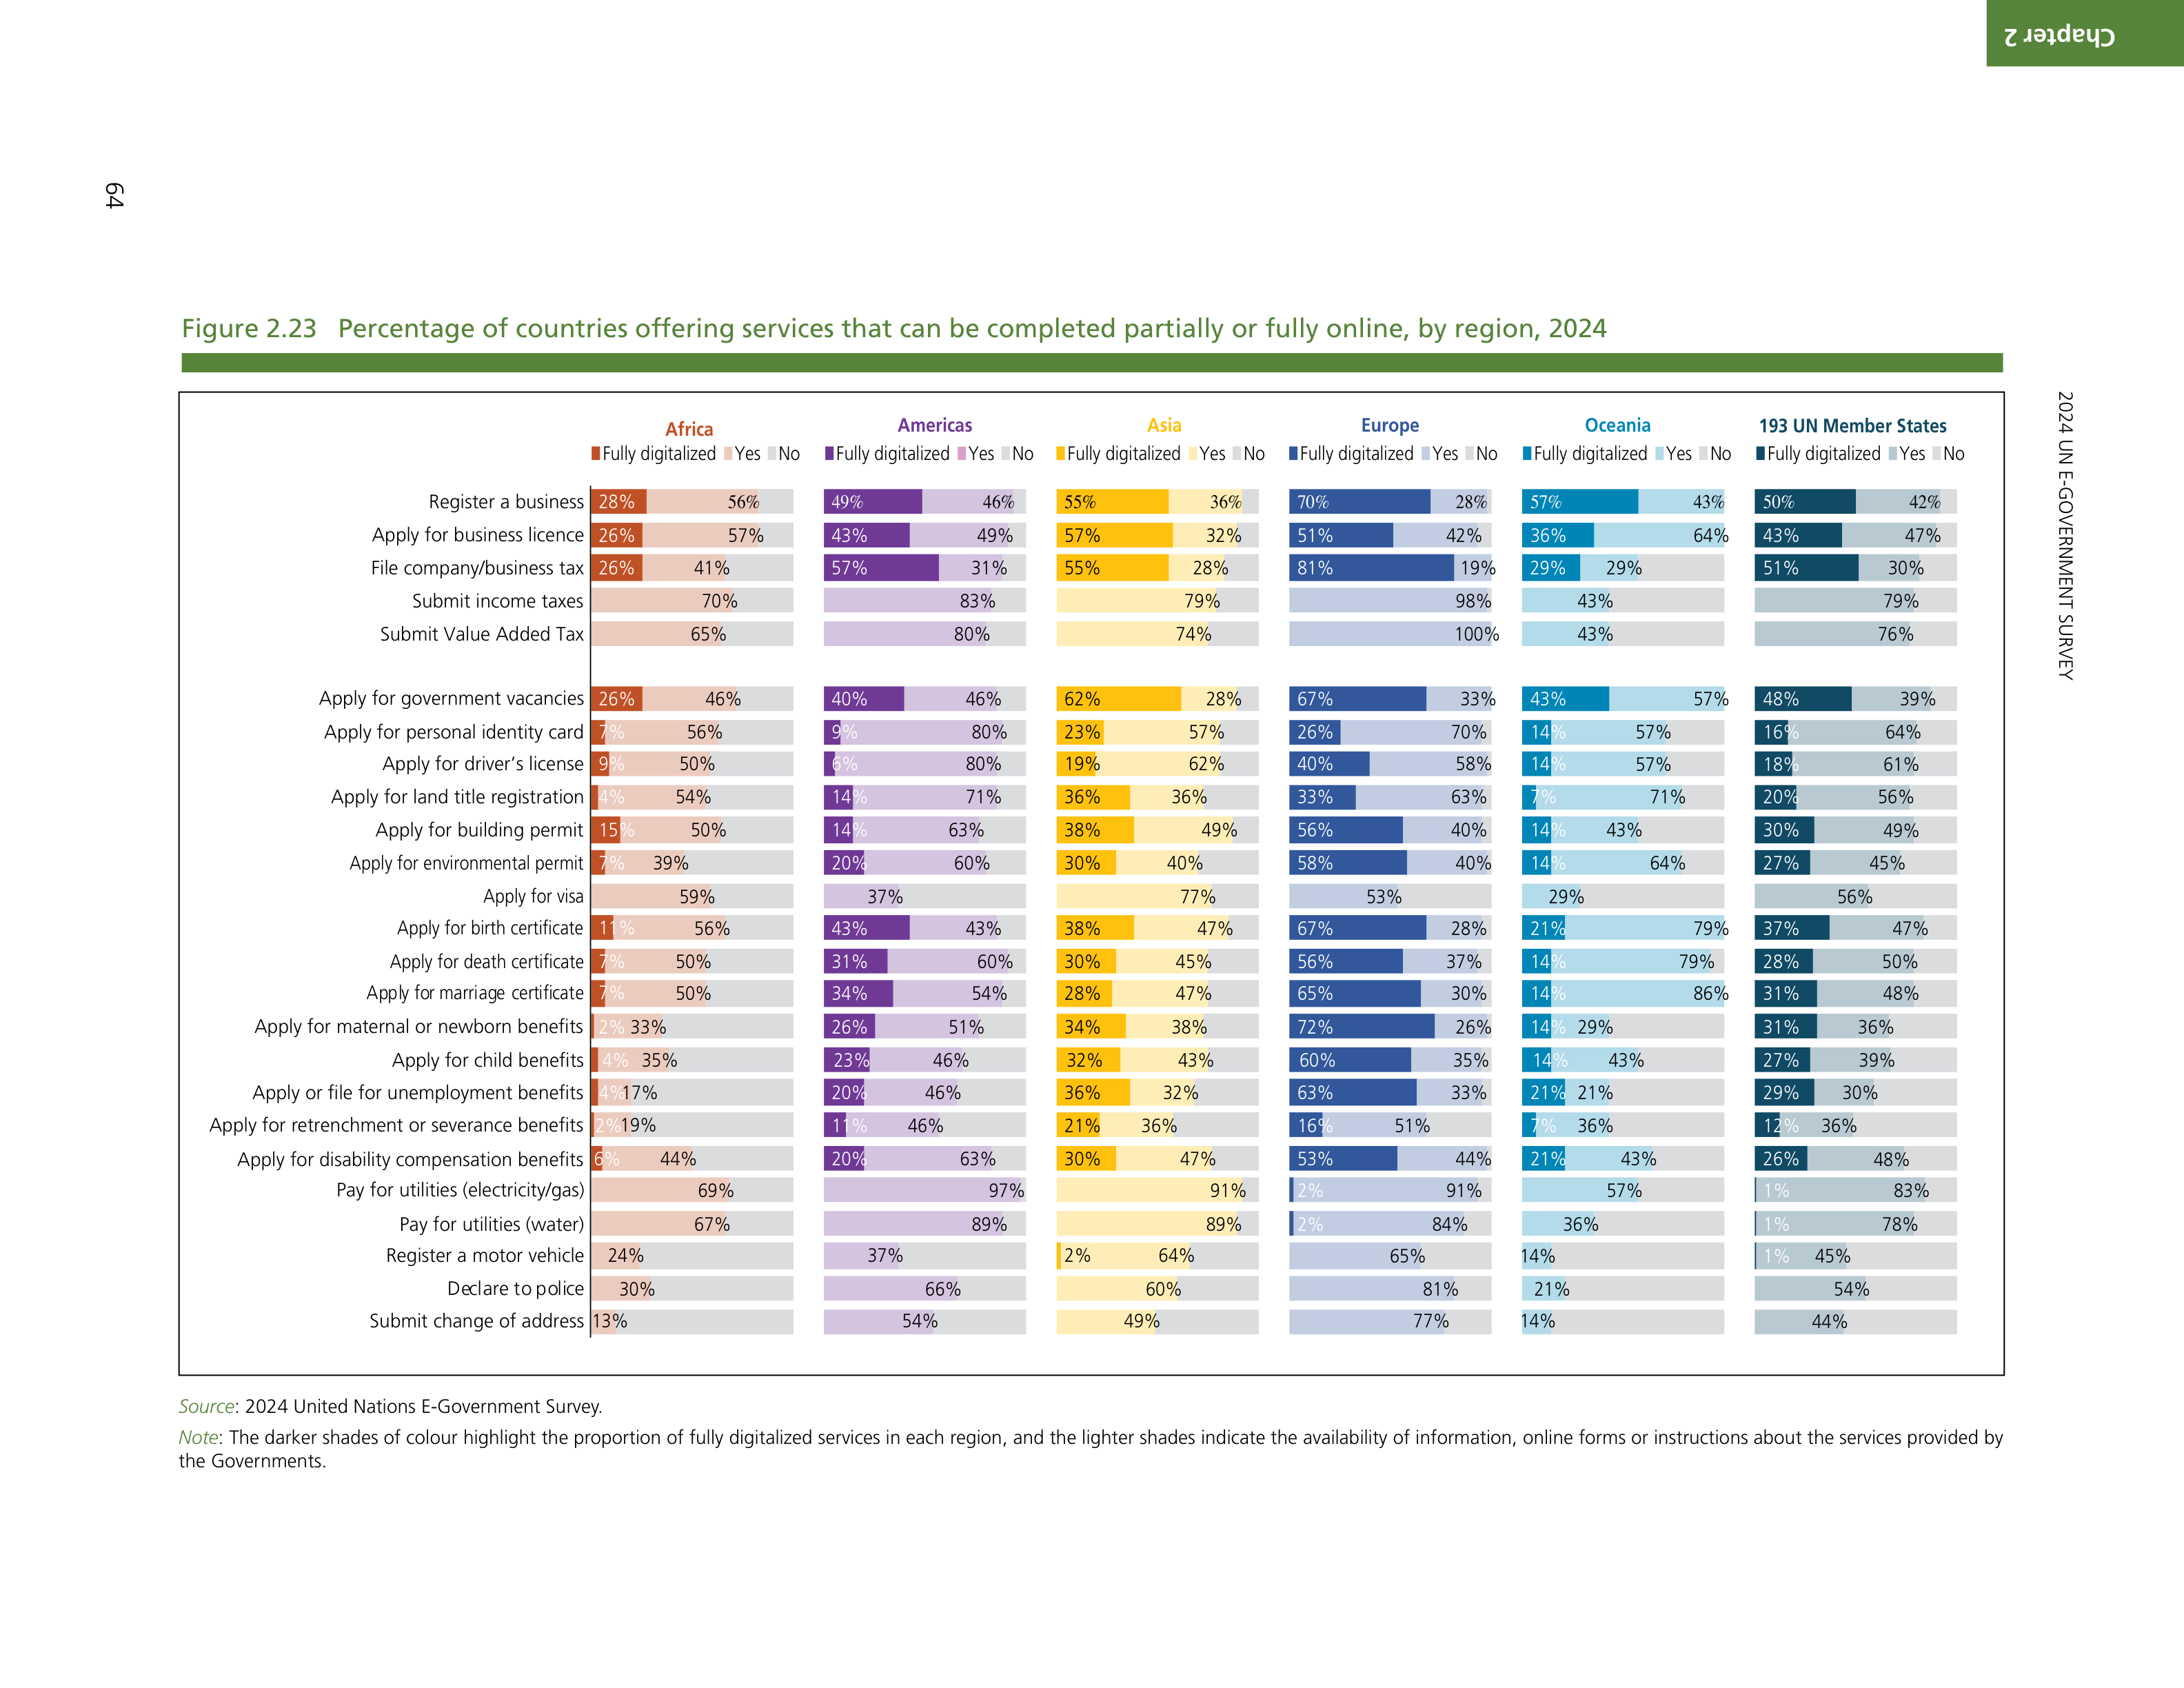

In [4]:
# ============================================================
# 58. RENDER A ROTATED PDF PAGE FOR INSPECTION
# ============================================================

from pathlib import Path
from PIL import Image as PILImage
from IPython.display import display, Image
import fitz


EGOV_PDF_PATH = (
    DATA_DIR
    / "Web Version _E-Government Survey 2024 11102024.pdf"
)

# PyMuPDF uses zero-based indexing internally.
# PDF page 90 means page_index = 89.
PDF_PAGE_NUMBER = 90

ROTATED_PAGE_DIR = (
    CACHE_DIR
    / "rotated_pages"
)

ROTATED_PAGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


def render_and_rotate_pdf_page(
    pdf_path: str,
    page_number: int,
    zoom: float = 4.0,
    clockwise: bool = True
) -> dict:
    """
    Render one PDF page and rotate the resulting image by 90 degrees.

    Use clockwise=True first.
    If the result appears upside down, rerun with clockwise=False.
    """

    pdf_path = Path(
        pdf_path
    )

    raw_image_path = (
        ROTATED_PAGE_DIR
        / (
            f"{safe_filename(pdf_path.stem)}"
            f"_page_{page_number}"
            f"_raw.png"
        )
    )

    rotation_label = (
        "clockwise"
        if clockwise
        else "counterclockwise"
    )

    rotated_image_path = (
        ROTATED_PAGE_DIR
        / (
            f"{safe_filename(pdf_path.stem)}"
            f"_page_{page_number}"
            f"_{rotation_label}.png"
        )
    )

    # --------------------------------------------------------
    # Render the original PDF page
    # --------------------------------------------------------

    with fitz.open(
        pdf_path
    ) as document:

        page_index = (
            page_number - 1
        )

        if (
            page_index < 0
            or page_index >= len(document)
        ):
            raise ValueError(
                f"PDF page {page_number} does not exist. "
                f"The document has {len(document)} pages."
            )

        page = document[
            page_index
        ]

        extracted_text = page.get_text(
            "text"
        ).strip()

        pixmap = page.get_pixmap(
            matrix=fitz.Matrix(
                zoom,
                zoom
            ),
            alpha=False
        )

        pixmap.save(
            str(
                raw_image_path
            )
        )

    # --------------------------------------------------------
    # Rotate the rendered image
    # --------------------------------------------------------

    raw_image = PILImage.open(
        raw_image_path
    )

    if clockwise:
        rotated_image = raw_image.transpose(
            PILImage.Transpose.ROTATE_270
        )

    else:
        rotated_image = raw_image.transpose(
            PILImage.Transpose.ROTATE_90
        )

    rotated_image.save(
        rotated_image_path
    )

    return {
        "pdf_path": str(
            pdf_path
        ),
        "page_number": page_number,
        "raw_image_path": str(
            raw_image_path
        ),
        "rotated_image_path": str(
            rotated_image_path
        ),
        "extracted_text": extracted_text,
        "rotation": rotation_label
    }


rotated_page_90 = render_and_rotate_pdf_page(
    pdf_path=str(
        EGOV_PDF_PATH
    ),
    page_number=PDF_PAGE_NUMBER,
    zoom=4.0,
    clockwise=True
)


print("=" * 100)
print("ROTATED PAGE INSPECTION")
print("=" * 100)

print("\nPDF:")
print(
    EGOV_PDF_PATH.name
)

print("\nPDF page:")
print(
    PDF_PAGE_NUMBER
)

print("\nRotation:")
print(
    rotated_page_90[
        "rotation"
    ]
)

print("\nNative extracted text preview:")
print(
    rotated_page_90[
        "extracted_text"
    ][:5000]
)

print("\nROTATED PAGE IMAGE:")

display(
    Image(
        filename=rotated_page_90[
            "rotated_image_path"
        ]
    )
)

In [5]:
# ============================================================
# DETECT QUESTIONS RELATED TO FIGURE 2.23
# ============================================================

from pathlib import Path
import re
import pandas as pd
from IPython.display import display


# ------------------------------------------------------------
# Use the readable rotated page image created earlier
# ------------------------------------------------------------

# ============================================================
# ROBUSTLY LOAD THE QA CSV
# ============================================================

from pathlib import Path
import csv
import pandas as pd


QA_PATH = Path(
    "/Users/lalitaneeharikavajjhala/Desktop/Hackathon2/qaSet.csv"
)


if not QA_PATH.exists():
    raise FileNotFoundError(
        f"QA CSV not found: {QA_PATH}"
    )


def load_qa_csv_robustly(
    csv_path: Path
) -> pd.DataFrame:
    """
    Load the organiser-provided QA file safely.

    The function:
    1. inspects the likely delimiter;
    2. tries the common separators;
    3. uses Pandas' Python parser for irregular rows;
    4. validates that a 'question' column exists.
    """

    csv_path = Path(
        csv_path
    )

    raw_preview = csv_path.read_text(
        encoding="utf-8",
        errors="ignore"
    )[:5000]

    try:
        detected_dialect = csv.Sniffer().sniff(
            raw_preview,
            delimiters=[
                ";",
                "\t",
                ",",
                "|"
            ]
        )

        detected_separator = (
            detected_dialect.delimiter
        )

    except csv.Error:
        detected_separator = None


    separators_to_try = []

    if detected_separator:
        separators_to_try.append(
            detected_separator
        )

    for separator in [
        ";",
        "\t",
        ",",
        "|"
    ]:
        if separator not in separators_to_try:
            separators_to_try.append(
                separator
            )


    loading_errors = []

    for separator in separators_to_try:

        try:
            candidate_df = pd.read_csv(
                csv_path,
                sep=separator,
                engine="python",
                encoding="utf-8",
                on_bad_lines="warn"
            )

            candidate_df.columns = [
                str(column).strip()
                for column in candidate_df.columns
            ]

            if "question" in candidate_df.columns:

                if "answer" not in candidate_df.columns:
                    candidate_df[
                        "answer"
                    ] = ""

                return (
                    candidate_df
                    .fillna("")
                    .reset_index(
                        drop=True
                    )
                )

        except Exception as error:
            loading_errors.append(
                (
                    separator,
                    str(
                        error
                    )
                )
            )


    raise ValueError(
        "Could not load qaSet.csv with a valid "
        "'question' column.\n\n"
        f"Separators tried: {separators_to_try}\n"
        f"Errors: {loading_errors}"
    )


qa_df = load_qa_csv_robustly(
    QA_PATH
)


print("=" * 100)
print("QA CSV LOADED SUCCESSFULLY")
print("=" * 100)

print("\nShape:")
print(
    qa_df.shape
)

print("\nColumns:")
print(
    qa_df.columns.tolist()
)

print("\nFirst 10 questions:")

display(
    qa_df.head(
        10
    )
)



if "rotated_page_90" not in globals():
    raise NameError(
        "The variable 'rotated_page_90' is missing. "
        "Run the page-rotation cell first."
    )

FIGURE_223_IMAGE_PATH = Path(
    rotated_page_90[
        "rotated_image_path"
    ]
)

if not FIGURE_223_IMAGE_PATH.exists():
    raise FileNotFoundError(
        f"Rotated page image not found: {FIGURE_223_IMAGE_PATH}"
    )


# ------------------------------------------------------------
# Row labels visible in Figure 2.23
# ------------------------------------------------------------

figure_223_service_keywords = [
    "register a business",
    "apply for business licence",
    "apply for business license",
    "file company tax",
    "business tax",
    "submit income tax",
    "submit value added tax",
    "submit vat",
    "government vacancies",
    "personal identity card",
    "driver's licence",
    "driver's license",
    "land title registration",
    "building permit",
    "environmental permit",
    "visa",
    "birth certificate",
    "death certificate",
    "marriage certificate",
    "maternity benefit",
    "newborn benefit",
    "child benefit",
    "unemployment benefit",
    "retirement benefit",
    "severance benefit",
    "disability compensation",
    "electricity",
    "gas",
    "water",
    "motor vehicle",
    "vehicle registration",
    "declare to police",
    "change of address"
]


def normalize_question_text(
    text: str
) -> str:
    """
    Normalise text and repair a few known spelling mistakes
    appearing in the QA questions.
    """

    normalized_text = str(
        text
    ).lower()

    replacements = {
        "regitration": "registration",
        "european": "europe",
        "digitised": "digitized",
        "digitalised": "digitalized"
    }

    for incorrect, corrected in replacements.items():
        normalized_text = normalized_text.replace(
            incorrect,
            corrected
        )

    return normalized_text


def is_figure_223_question(
    question: str
) -> bool:
    """
    Flag questions likely to be answered by Figure 2.23.
    """

    question_normalized = normalize_question_text(
        question
    )

    return any(
        keyword in question_normalized
        for keyword in figure_223_service_keywords
    )


figure_223_candidate_questions_df = (
    qa_df[
        qa_df[
            "question"
        ]
        .apply(
            is_figure_223_question
        )
    ]
    .copy()
    .reset_index()
    .rename(
        columns={
            "index": "question_index"
        }
    )
)


print("=" * 100)
print("QUESTIONS LIKELY ANSWERED BY FIGURE 2.23")
print("=" * 100)

print(
    "\nNumber of matching questions:",
    len(
        figure_223_candidate_questions_df
    )
)

display(
    figure_223_candidate_questions_df[
        [
            "question_index",
            "question"
        ]
    ]
)

QA CSV LOADED SUCCESSFULLY

Shape:
(40, 2)

Columns:
['question', 'answer']

First 10 questions:


,question,answer
0,What year where there most casualties from man...,"2002. In that year more than 10,000 casualties..."
1,In what year did the quantity of man-made disa...,Man-made disasters peaked in 2005
2,Between 1970 and 2023 what year in the data sh...,2023. There were 218 instances of natural cat...
3,What year between 1994 and 2023 had the most h...,2011 with 6.
4,How much higher are the 2023 insured losses th...,They are higher by 21%.
5,Which figure shows the trend in insured losses...,
6,"Before 2023, what was the highest year on reco...",
7,What regions does the Swiss Re report on natur...,
8,What is the highest Benefit to Cost ratio buil...,
9,According to the Swiss Re Institute report on ...,


QUESTIONS LIKELY ANSWERED BY FIGURE 2.23

Number of matching questions: 3


,question_index,question
0,24,In what percentage of countries in Oceania is ...
1,25,What region of the world contains the countrie...
2,26,In what percentage of countries in the America...


In [6]:
# ============================================================
# INSTALL OPENAI PYTHON SDK
# ============================================================

%pip install --upgrade openai


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
from openai import OpenAI

In [8]:
# ============================================================
# GENERATE ANSWERS FROM ROTATED FIGURE 2.23 AND SAVE NEW_FINAL.CSV
# ============================================================

from pathlib import Path
from getpass import getpass
import base64
import mimetypes
import os
import re

import pandas as pd
from tqdm.auto import tqdm
from openai import OpenAI
from IPython.display import display


# ------------------------------------------------------------
# 1. SET PROJECT PATHS
# ------------------------------------------------------------

PROJECT_DIR = (
    Path.home()
    / "Desktop"
    / "Hackathon2"
)

OUTPUT_DIR = (
    PROJECT_DIR
    / "Outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. CONNECT TO THE ORGANISER API
# ------------------------------------------------------------

ORGANISER_BASE_URL = (
    "https://api.swissai.svc.cscs.ch/v1"
)

CSCS_API_KEY = os.getenv(
    "CSCS_API_KEY"
)

if not CSCS_API_KEY:
    CSCS_API_KEY = getpass(
        "Enter the organiser-provided API key: "
    )


client_cscs = OpenAI(
    base_url=ORGANISER_BASE_URL,
    api_key=CSCS_API_KEY
)


VISION_MODEL = (
    "moonshotai/Kimi-K2.5-SDSC"
)


# ------------------------------------------------------------
# 3. LOCATE THE READABLE ROTATED IMAGE
# ------------------------------------------------------------

if "rotated_page_90" not in globals():
    raise NameError(
        "The variable 'rotated_page_90' is missing. "
        "Run the page-rendering and rotation cell first."
    )


FIGURE_223_IMAGE_PATH = Path(
    rotated_page_90[
        "rotated_image_path"
    ]
)

if not FIGURE_223_IMAGE_PATH.exists():
    raise FileNotFoundError(
        f"Rotated Figure 2.23 image not found: "
        f"{FIGURE_223_IMAGE_PATH}"
    )


# ------------------------------------------------------------
# 4. ENCODE THE IMAGE
# ------------------------------------------------------------

def encode_image_as_data_url(
    image_path: Path
) -> str:
    """
    Convert a local image into a Base64 data URL.
    """

    image_path = Path(
        image_path
    )

    mime_type, _ = mimetypes.guess_type(
        str(
            image_path
        )
    )

    if mime_type is None:
        mime_type = "image/png"

    with open(
        image_path,
        "rb"
    ) as image_file:

        encoded_image = base64.b64encode(
            image_file.read()
        ).decode(
            "utf-8"
        )

    return (
        f"data:{mime_type};base64,"
        f"{encoded_image}"
    )


figure_223_data_url = encode_image_as_data_url(
    FIGURE_223_IMAGE_PATH
)


# ------------------------------------------------------------
# 5. CLEAN MODEL OUTPUT
# ------------------------------------------------------------

def clean_generated_answer(
    raw_answer: str
) -> str:
    """
    Remove exposed reasoning tags and return the concise answer.
    """

    answer = str(
        raw_answer
    ).strip()

    answer = re.sub(
        r"<think>.*?</think>",
        "",
        answer,
        flags=re.DOTALL
        | re.IGNORECASE
    ).strip()

    return answer


# ------------------------------------------------------------
# 6. ASK KIMI ONE QUESTION AT A TIME
# ------------------------------------------------------------

def answer_from_figure_223(
    question: str,
    model: str = VISION_MODEL
) -> str:
    """
    Answer one Figure 2.23 question using the readable rotated chart.

    Chart interpretation:
    - darker coloured segment = fully digitalized
    - lighter coloured segment labelled Yes = partially online
    - grey segment labelled No = unavailable
    """

    prompt = f"""
You are reading Figure 2.23 from the 2024 UN E-Government Survey.

FIGURE TITLE:
Percentage of countries offering services that can be completed
partially or fully online, by region, 2024.

QUESTION:
{question}

IMPORTANT CHART RULES:
1. Read the exact service row and geographical region carefully.
2. The darker coloured segment represents the percentage of countries
   where the service is fully digitalized.
3. The lighter coloured segment labelled Yes represents partial online
   availability, such as information, forms or instructions.
4. The grey segment labelled No represents countries without the service.
5. If the question asks for a fully digitalized process, use only the
   darker coloured segment.
6. If the question asks for at least partial online availability, add:
       fully digitalized percentage + lighter-shade Yes percentage
7. If the question asks which region contains countries offering the
   service, compare all regions.
8. Answer every part of the question.
9. Preserve exact percentages from the chart.
10. Return one concise final answer only.
11. Do not include reasoning or analysis.
""".strip()

    response = (
        client_cscs
        .chat
        .completions
        .create(
            model=model,
            messages=[
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "text",
                            "text": prompt
                        },
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": (
                                    figure_223_data_url
                                )
                            }
                        }
                    ]
                }
            ],
            temperature=0
        )
    )

    raw_answer = (
        response
        .choices[0]
        .message
        .content
    )

    return clean_generated_answer(
        raw_answer
    )


# ------------------------------------------------------------
# 7. GENERATE ANSWERS FOR DETECTED QUESTIONS
# ------------------------------------------------------------

generated_records = []

for _, row in tqdm(
    figure_223_candidate_questions_df.iterrows(),
    total=len(
        figure_223_candidate_questions_df
    ),
    desc="Generating Figure 2.23 answers"
):

    question_index = int(
        row[
            "question_index"
        ]
    )

    question = row[
        "question"
    ]

    try:
        generated_answer = answer_from_figure_223(
            question=question
        )

    except Exception as error:
        generated_answer = (
            f"PIPELINE_ERROR: {error}"
        )

    generated_records.append({
        "question_index": question_index,
        "question": question,
        "generated_answer": generated_answer
    })


figure_223_answers_df = pd.DataFrame(
    generated_records
)


print("=" * 100)
print("GENERATED FIGURE 2.23 ANSWERS")
print("=" * 100)

display(
    figure_223_answers_df
)


# ------------------------------------------------------------
# 8. LOAD THE LATEST EXISTING PREDICTIONS IF AVAILABLE
# ------------------------------------------------------------

existing_prediction_candidates = [
    OUTPUT_DIR
    / "new_final.csv",

    OUTPUT_DIR
    / "final_predictions_for_testing.csv"
]


existing_predictions_path = next(
    (
        path
        for path in existing_prediction_candidates
        if path.exists()
    ),
    None
)


if existing_predictions_path is None:

    new_final_df = (
        qa_df[
            [
                "question"
            ]
        ]
        .copy()
        .reset_index()
        .rename(
            columns={
                "index": "question_index"
            }
        )
    )

    new_final_df[
        "final_answer"
    ] = ""

else:

    print(
        "\nLoading existing predictions from:"
    )

    print(
        existing_predictions_path
    )

    new_final_df = pd.read_csv(
        existing_predictions_path
    )


# ------------------------------------------------------------
# 9. NORMALISE COLUMN NAMES
# ------------------------------------------------------------

if (
    "question_index"
    not in new_final_df.columns
):

    new_final_df = (
        new_final_df
        .reset_index()
        .rename(
            columns={
                "index": "question_index"
            }
        )
    )


if (
    "final_answer"
    not in new_final_df.columns
):

    if (
        "answer"
        in new_final_df.columns
    ):

        new_final_df = new_final_df.rename(
            columns={
                "answer": "final_answer"
            }
        )

    elif (
        "predicted_answer"
        in new_final_df.columns
    ):

        new_final_df = new_final_df.rename(
            columns={
                "predicted_answer": (
                    "final_answer"
                )
            }
        )

    else:

        new_final_df[
            "final_answer"
        ] = ""


# ------------------------------------------------------------
# 10. UPDATE THE THREE GENERATED ANSWERS
# ------------------------------------------------------------

for _, generated_row in (
    figure_223_answers_df
    .iterrows()
):

    matching_rows = (
        new_final_df[
            "question_index"
        ]
        .astype(int)
        .eq(
            int(
                generated_row[
                    "question_index"
                ]
            )
        )
    )

    new_final_df.loc[
        matching_rows,
        "final_answer"
    ] = generated_row[
        "generated_answer"
    ]


# ------------------------------------------------------------
# 11. SAVE NEW_FINAL.CSV
# ------------------------------------------------------------

NEW_FINAL_PATH = (
    OUTPUT_DIR
    / "new_final.csv"
)

new_final_df.to_csv(
    NEW_FINAL_PATH,
    index=False
)


print("\n" + "=" * 100)
print("NEW FINAL CSV SAVED")
print("=" * 100)

print("\nSaved to:")
print(
    NEW_FINAL_PATH
)

print("\nUpdated rows:")

display(
    new_final_df[
        new_final_df[
            "question_index"
        ]
        .astype(int)
        .isin(
            figure_223_answers_df[
                "question_index"
            ]
            .astype(int)
        )
    ][
        [
            "question_index",
            "question",
            "final_answer"
        ]
    ]
    .sort_values(
        "question_index"
    )
)


Generating Figure 2.23 answers: 100%|██████████| 3/3 [02:07<00:00, 42.56s/it]

GENERATED FIGURE 2.23 ANSWERS


,question_index,question,generated_answer
0,24,In what percentage of countries in Oceania is ...,14%
1,25,What region of the world contains the countrie...,"Americas, 37%"
2,26,In what percentage of countries in the America...,83%



Loading existing predictions from:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Outputs/new_final.csv

NEW FINAL CSV SAVED

Saved to:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Outputs/new_final.csv

Updated rows:


,question_index,question,final_answer
24,24,In what percentage of countries in Oceania is ...,14%
25,25,What region of the world contains the countrie...,"Americas, 37%"
26,26,In what percentage of countries in the America...,83%


In [11]:
# ============================================================
# UPDATE FIGURE 2.23 ANSWERS USING COMPLETE, EVALUATOR-FRIENDLY TEXT
# ============================================================

from pathlib import Path
import pandas as pd


INPUT_CSV_PATH = (
    Path.home()
    / "Desktop"
    / "Hackathon2"
    / "Outputs"
    / "new_final.csv"
)

OUTPUT_CSV_PATH = (
    Path.home()
    / "Desktop"
    / "Hackathon2"
    / "Outputs"
    / "new_final_v2.csv"
)


# ------------------------------------------------------------
# 1. Load the latest CSV
# ------------------------------------------------------------

predictions_df = pd.read_csv("//Users//lalitaneeharikavajjhala//Desktop//new_final_v2_csv.csv"
    
)


# ------------------------------------------------------------
# 2. Detect the answer column safely
# ------------------------------------------------------------

if "final_answer" in predictions_df.columns:
    answer_column = "final_answer"

elif "answer" in predictions_df.columns:
    answer_column = "answer"

elif "predicted_answer" in predictions_df.columns:
    answer_column = "predicted_answer"

else:
    raise ValueError(
        "Could not find an answer column. "
        f"Available columns: {predictions_df.columns.tolist()}"
    )


# ------------------------------------------------------------
# 3. Ensure a question_index column exists
# ------------------------------------------------------------

if "question_index" not in predictions_df.columns:

    predictions_df = (
        predictions_df
        .reset_index()
        .rename(
            columns={
                "index": "question_index"
            }
        )
    )


# ------------------------------------------------------------
# 4. Replace the four Figure 2.23 answers
# ------------------------------------------------------------

figure_223_answer_updates = {

    23: (
        "98% of European countries support filing income tax online."
    ),

    24: (
        "14% of countries in Oceania support a fully digitized "
        "process for applying for a death certificate."
    ),

    25: (
        "Asia contains the countries offering fully digitized "
        "motor-vehicle registration; 2% of countries in the region "
        "support it."
    ),

    26: (
        "83% of countries in the Americas support applying for "
        "disability compensation in at least a partially online "
        "manner: 20% fully digitized and 63% partially online."
    )
}


for question_index, updated_answer in (
    figure_223_answer_updates.items()
):

    row_mask = (
        predictions_df[
            "question_index"
        ]
        .astype(int)
        .eq(
            question_index
        )
    )

    predictions_df.loc[
        row_mask,
        answer_column
    ] = updated_answer


# ------------------------------------------------------------
# 5. Save a new version
# ------------------------------------------------------------

predictions_df.to_csv(
    OUTPUT_CSV_PATH,
    index=False
)


print("=" * 100)
print("UPDATED CSV SAVED")
print("=" * 100)

print("\nSaved to:")
print(
    OUTPUT_CSV_PATH
)

print("\nUpdated Figure 2.23 rows:")

display(
    predictions_df[
        predictions_df[
            "question_index"
        ]
        .astype(int)
        .isin(
            figure_223_answer_updates.keys()
        )
    ][
        [
            "question_index",
            "question",
            answer_column
        ]
    ]
    .sort_values(
        "question_index"
    )
)

UPDATED CSV SAVED

Saved to:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Outputs/new_final_v2.csv

Updated Figure 2.23 rows:


,question_index,question,answer
23,23,What percentage of european countries support ...,98% of European countries support filing incom...
24,24,In what percentage of countries in Oceania is ...,14% of countries in Oceania support a fully di...
25,25,What region of the world contains the countrie...,Asia contains the countries offering fully dig...
26,26,In what percentage of countries in the America...,83% of countries in the Americas support apply...


In [13]:
# ============================================================
# PATCH NEW_FINAL_V2 AND SAVE A SAFER SUBMISSION FILE
# ============================================================

from pathlib import Path
import pandas as pd


PROJECT_DIR = (
    Path.home()
    / "Desktop"
)

INPUT_CSV_PATH = (
    PROJECT_DIR
    / "new_final_v2_csv.csv"
)

OUTPUT_CSV_PATH = (
    PROJECT_DIR
    / "final_submission_v3.csv"
)


# ------------------------------------------------------------
# 1. Load the latest file
# ------------------------------------------------------------

submission_df = pd.read_csv(
    INPUT_CSV_PATH
)


if "answer" not in submission_df.columns:
    raise ValueError(
        "Expected a column called 'answer'. "
        f"Found: {submission_df.columns.tolist()}"
    )


if len(submission_df) != 40:
    raise ValueError(
        f"Expected 40 rows, but found {len(submission_df)}."
    )


# ------------------------------------------------------------
# 2. Apply corrections
# ------------------------------------------------------------

answer_updates = {

    11: (
        "Africa has the smallest proportion of insured losses "
        "relative to uninsured losses between 2014 and 2023."
    ),

    14: (
        "There was a three-way tie for the largest increase "
        "between 2022 and 2024, at 6 percentage points: "
        "portals updated within the last month increased from "
        "83% to 89%; businesses able to access their own data "
        "online increased from 65% to 71%; and individuals able "
        "to modify their own data online increased from 50% to 56%."
    ),

    18: (
        "Yes. Questions #21 and #22 are missing from the displayed "
        "sequence, which moves from #20 to #23."
    ),

    20: (
        "Rwanda has the lowest Telecommunications Infrastructure "
        "Index level among the listed countries with very high "
        "OSI levels and divergent EGDI components."
    ),

    21: (
        "The Americas have the OSI subindex average closest to "
        "the overall UN 193 average: 0.5797, compared with the "
        "global average of 0.5754."
    ),

    23: (
        "98% of European countries support filing income tax online."
    ),

    24: (
        "14% of countries in Oceania allow users to apply for "
        "a death certificate through a fully digitized process."
    ),

    25: (
        "Asia is the region containing countries that enable "
        "fully digitized motor-vehicle registration. "
        "The proportion is 2%."
    ),

    26: (
        "83% of countries in the Americas allow users to apply "
        "for disability compensation in at least a partially "
        "online manner: 20% fully digitized and 63% partially online."
    ),

    28: (
        "40 countries in Europe offer an e-procurement platform."
    ),

    34: (
        "Japan named the project the Digital Garden City Nation "
        "Initiative. Its initial budget was USD 42 billion."
    ),

    36: (
        "Oceania appears to have the most drastic variation in "
        "EGDI levels among its constituent countries. EGDI values "
        "range from 0.3076 to 0.9577."
    ),

    # Do not submit the unrelated 2025 energy-total answer.
    38: (
        "VISUAL_EVIDENCE_REQUIRED"
    ),

    39: (
        "Three of the top 10 costliest economic-loss events of "
        "2023 occurred in Latin America. Mexico faced the most "
        "expensive one: Hurricane Otis."
    )
}


for question_index, corrected_answer in (
    answer_updates.items()
):

    submission_df.loc[
        question_index,
        "answer"
    ] = corrected_answer


# ------------------------------------------------------------
# 3. Save only the required columns
# ------------------------------------------------------------

submission_df[
    [
        "question",
        "answer"
    ]
].to_csv(
    OUTPUT_CSV_PATH,
    index=False
)


# ------------------------------------------------------------
# 4. Verify the patched rows
# ------------------------------------------------------------

print("=" * 100)
print("FINAL SUBMISSION V3 CREATED")
print("=" * 100)

print("\nSaved to:")
print(
    OUTPUT_CSV_PATH
)

print("\nPatched rows:")

display(
    submission_df.loc[
        sorted(
            answer_updates.keys()
        ),
        [
            "question",
            "answer"
        ]
    ]
)

FINAL SUBMISSION V3 CREATED

Saved to:
/Users/lalitaneeharikavajjhala/Desktop/final_submission_v3.csv

Patched rows:


,question,answer
11,In historical data from the Swiss Re Institute...,Africa has the smallest proportion of insured ...
14,"According to survey data, which feature of gov...",There was a three-way tie for the largest incr...
18,Of the questions highlighted from the Member S...,Yes. Questions #21 and #22 are missing from th...
20,Of the countries with very high OSI levels and...,Rwanda has the lowest Telecommunications Infra...
21,What grouping of nations has the closest OSI s...,The Americas have the OSI subindex average clo...
23,What percentage of european countries support ...,98% of European countries support filing incom...
24,In what percentage of countries in Oceania is ...,14% of countries in Oceania allow users to app...
25,What region of the world contains the countrie...,Asia is the region containing countries that e...
26,In what percentage of countries in the America...,83% of countries in the Americas allow users t...
28,What number of countries in Europe offer an E-...,40 countries in Europe offer an e-procurement ...
